The dataset 'trees' contains information about the diameter, height, and wood volume of 31 felled cherry trees. Check for outliers using Isolation Forests. Draw a scatter plot where the X-axis represents the diameter, the Y-axis represents the height, and the color of the point depends on whether it is an outlier or not.

1. Ryan, T. A., Joiner, B. L. and Ryan, B. F. (1976) The Minitab Student Handbook. Duxbury Press.
2. Atkinson, A. C. (1985) Plots, Transformations and Regression. Oxford University Press.

,Diameter,Height,Volume,iso_scores,iso_outlierness
0,8.3,70,10.3,-1,-0.051822
1,8.6,65,10.3,-1,-0.045964
2,8.8,63,10.2,-1,-0.085184
3,10.5,72,16.4,1,0.047173
4,10.7,81,18.8,1,0.064850
5,10.8,83,19.7,1,0.047234
6,11.0,66,15.6,1,0.015647
7,11.0,75,18.2,1,0.102036
8,11.1,80,22.6,1,0.087525
9,11.2,75,19.9,1,0.112296


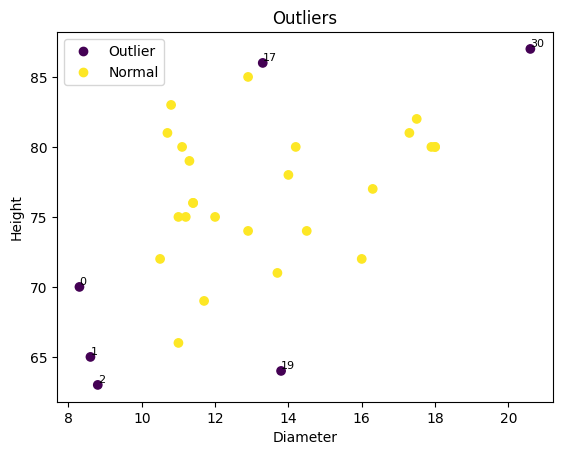

In [50]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
df = pd.read_csv('../data/trees.csv')

iso_forest = IsolationForest(
    contamination=0.2, # ustawienie maksymalnej liczby anomalii na 15%
    n_estimators=2000, # liczba drzew w lesie (liczba prób losowych)
    max_features=0.67, # użycie dwóch z trzech cech
)
iso_scores = iso_forest.fit_predict(df)
df = df.assign(
    iso_scores=iso_scores,
    iso_outlierness=iso_forest.decision_function(df)
)
display(df)

# Znalezienie i opisanie najbardziej odstających punktów
most_outlying = np.argmin(df['iso_outlierness'])  # Najbardziej odstający według Isolation Forest
df.iloc[most_outlying]
scatter = plt.scatter(
    df['Diameter'],
    df['Height'],
    c = df['iso_scores']
)

# Wyświetlenie indexu dla punktów oznaczonych jako outliers
for idx, row in df.iterrows():
    if row['iso_scores'] == -1:
        plt.annotate(idx, (row['Diameter'], row['Height']), fontsize=8, ha='left', va='bottom')

plt.xlabel('Diameter')
plt.ylabel('Height')
plt.title('Outliers')
plt.legend(
    handles = scatter.legend_elements()[0],
    labels = ['Outlier', 'Normal']
)
plt.show()